In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

In [26]:
# 1. Load the dataset from activity.csv
df = pd.read_csv('activity.csv')

In [27]:
# 2. Define Feature (X) and Target (y)
# 'No.of MOnths' predicts 'Copies .Sold'
X = df[['No.of MOnths']]
y = df['Copies .Sold']

In [28]:
# 3. Split into Training (70%) and Testing (30%) datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [29]:
# 4. Predict November (11) and December (12)
future_df = pd.DataFrame({'No.of MOnths': [11, 12]})
future_preds = model.predict(future_df)

In [30]:
# 5. Plotting All 12 Months
plt.figure(figsize=(11, 6))

<Figure size 1100x600 with 0 Axes>

<Figure size 1100x600 with 0 Axes>

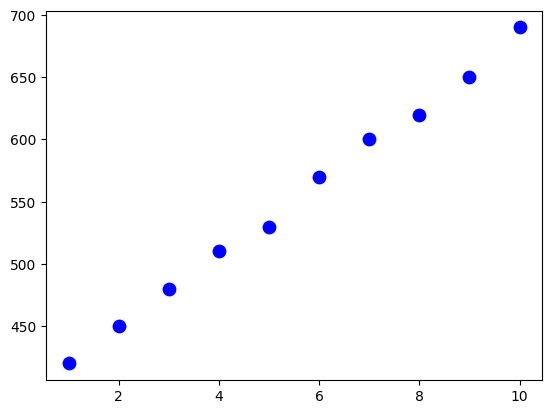

In [31]:
# Plot 10 actual CSV data points
plt.scatter(df['No.of MOnths'], df['Copies .Sold'], color='blue', label='Actual CSV Data (Months 1–10)', s=80, zorder=3)

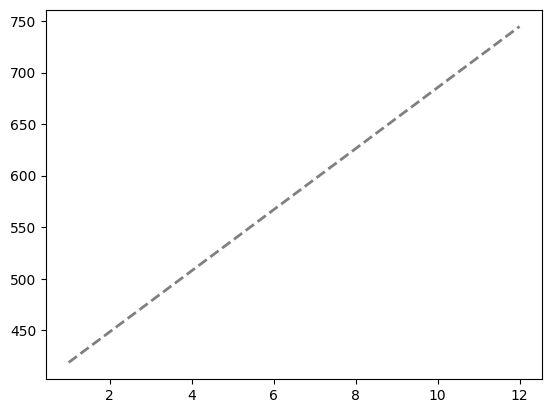

In [32]:
# Draw Regression Trend Line across 12 months
X_line = np.linspace(1, 12, 100).reshape(-1, 1)
y_line = model.predict(pd.DataFrame(X_line, columns=['No.of MOnths']))
plt.plot(X_line, y_line, color='gray', linestyle='--', label='Linear Regression Line', linewidth=2)

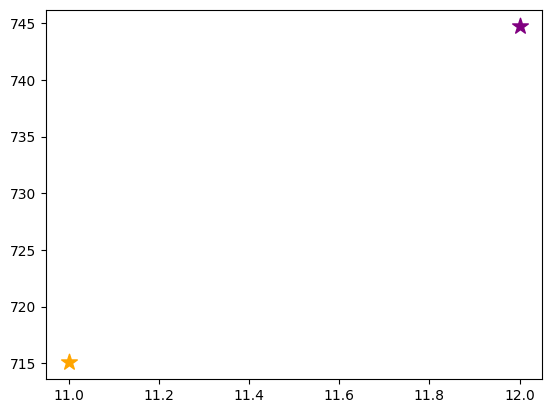

In [33]:
# Plot predictions for Months 11 and 12
plt.scatter(11, future_preds[0], color='orange', label=f'Month 11 (Nov): {future_preds[0]:.0f}', s=140, marker='*', zorder=4)
plt.scatter(12, future_preds[1], color='purple', label=f'Month 12 (Dec): {future_preds[1]:.0f}', s=140, marker='*', zorder=4)

Text(0, 10, '745')

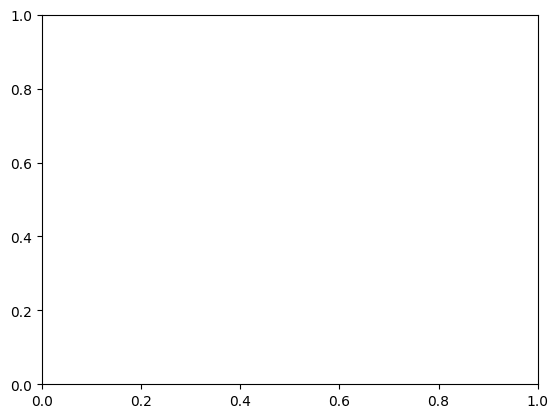

In [34]:
# Data point labels
for i, row in df.iterrows():
    plt.annotate(f"{int(row['Copies .Sold'])}", (row['No.of MOnths'], row['Copies .Sold']), textcoords="offset points", xytext=(0,8), ha='center', fontsize=9)

plt.annotate(f"{future_preds[0]:.0f}", (11, future_preds[0]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, fontweight='bold', color='darkorange')
plt.annotate(f"{future_preds[1]:.0f}", (12, future_preds[1]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, fontweight='bold', color='purple')

/tmp/ipykernel_3855/638813076.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left', fontsize=10)


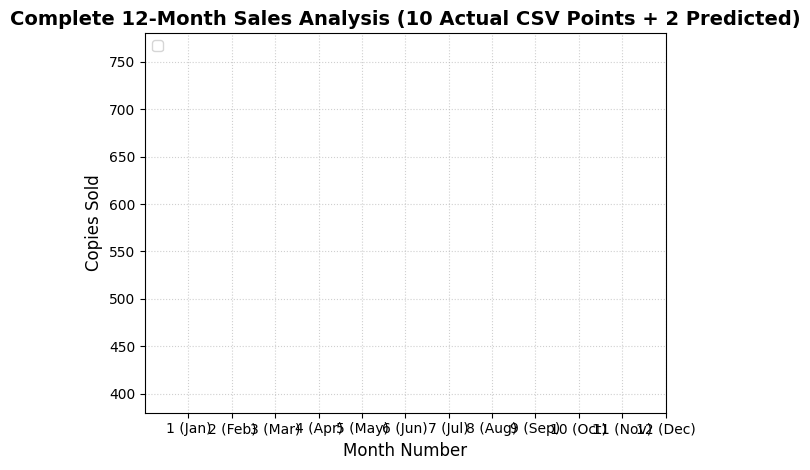

In [35]:
# Graph styling
plt.title('Complete 12-Month Sales Analysis (10 Actual CSV Points + 2 Predicted)', fontsize=14, fontweight='bold')
plt.xlabel('Month Number', fontsize=12)
plt.ylabel('Copies Sold', fontsize=12)
plt.xticks(range(1, 13), ['1 (Jan)', '2 (Feb)', '3 (Mar)', '4 (Apr)', '5 (May)', '6 (Jun)', '7 (Jul)', '8 (Aug)', '9 (Sep)', '10 (Oct)', '11 (Nov)', '12 (Dec)'])
plt.ylim(380, 780)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('all_12_points_plot.png', dpi=300)
plt.show()